In [1]:
import torch
from src.model import TransformDecoder, ImageTransformPredictor
from src.dataset import ImageTransformer, TransformTokenizer
from src.dataset import DomainNetDataset, get_domainnet_dataloaders
from PIL import Image
from omegaconf import OmegaConf
from torchvision import transforms
import time
from tqdm import tqdm
import numpy as np


%load_ext autoreload
%autoreload 2

In [2]:
# !pip install efficientnet_pytorch
# !pip install --upgrade torchvision

In [3]:
# /home/jovyan/.mlspace/envs/genimages

### Testing Model

In [39]:
config = OmegaConf.load('configs/train_config_011.yaml')

# preprocess = transforms.Compose([
#             transforms.Resize((224, 224)),
#             transforms.ToTensor(),
#             transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
#         ])

preprocess = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

In [40]:
model = ImageTransformPredictor(config.model)

Loaded pretrained weights for efficientnet-b3


In [4]:
# model.load_state_dict(torch.load('checkpoints/itp_011/model_weights.pth'))
# model.to('cpu')
# model.eval()
# print('ready')

In [41]:
# checkpoint_path = 'checkpoints/itp_vit/checkpoint_epoch_100.pth'
# checkpoint_path = 'checkpoints/itp_011/checkpoint_epoch_50.pth'
# checkpoint_path = 'checkpoints/itp_010/checkpoint_epoch_16.pth' # хороший у 010
# checkpoint_path = 'checkpoints/itp_009/checkpoint_epoch_20.pth'
# checkpoint_path = 'checkpoints/itp_vit_tune_full/checkpoint_epoch_17.pth'
checkpoint_path = 'checkpoints/itp_011_tune_full/checkpoint_epoch_15.pth'

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to('cpu')
model.eval()
print('ready')

ready


In [5]:
# torch.save(model.state_dict(), 'checkpoints/itp_vit/model_weights.pth')

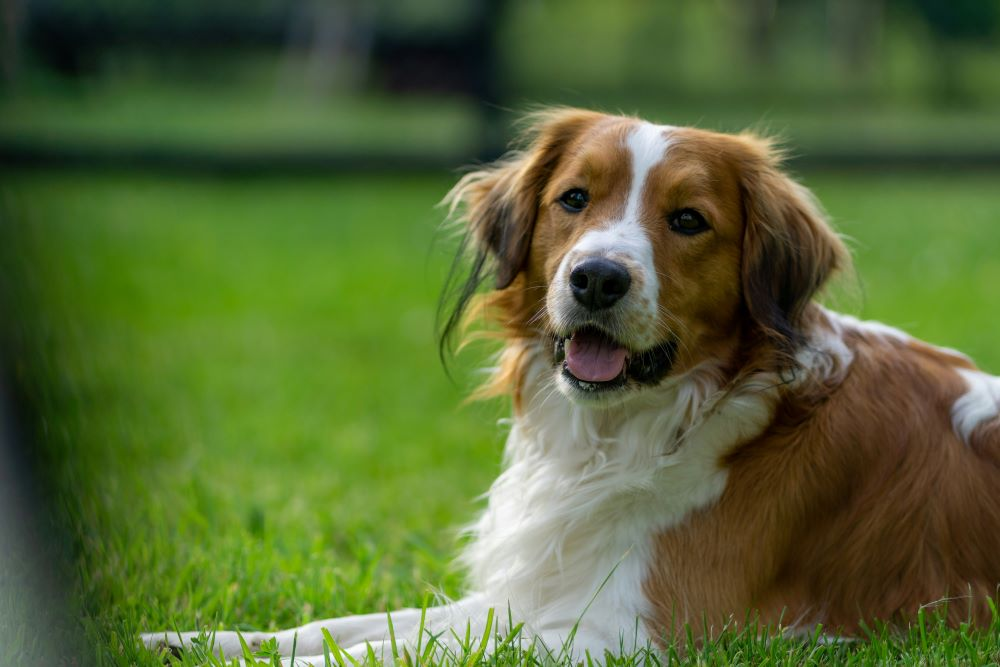

In [6]:
image_path_1 = 'assets/image.jpg'
image_path_2 = 'assets/dog.jpg'

image_1 = Image.open(image_path_1)
image_2 = Image.open(image_path_2)
image_1

['jpeg_artefacts', 'grayscale', 'rotate_90', 'horizontal_flip']


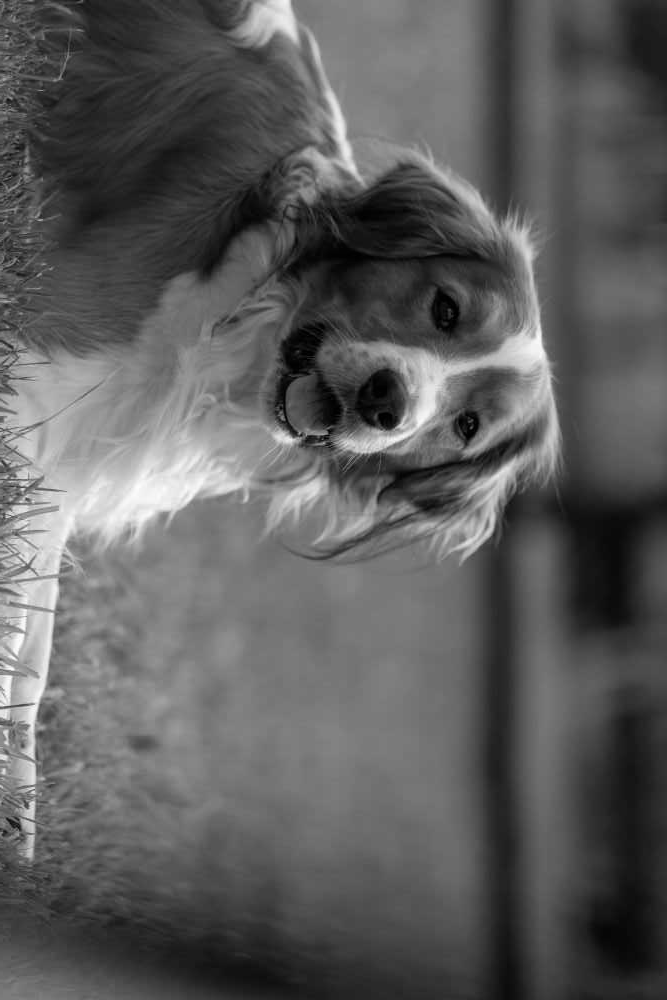

In [21]:
image_path_1 = 'assets/image.jpg'
image_path_2 = 'assets/dog.jpg'

image_1 = Image.open(image_path_1)
image_2 = Image.open(image_path_2)

it = ImageTransformer()
transformed_image_1, sequence_1 = it.transform(image_1, 0.3)
print(sequence_1)
transformed_image_1

In [22]:
image_tensor_1 = preprocess(image_1).unsqueeze(0)
image_tensor_2 = preprocess(image_2).unsqueeze(0)
transformed_image_tensor = preprocess(transformed_image_1).unsqueeze(0)

generated = model.generate(image_tensor_1, transformed_image_tensor, max_new_tokens=10, do_sample=False)
# generated = model.generate(image_tensor_1, transformed_image_tensor, max_new_tokens=10, do_sample=True, top_k=3)

tokenizer = TransformTokenizer()
tokens = tokenizer.decode(generated[0], skip_special_tokens=True)
print(f"Predicted: {tokens}")
print(f"Target: {sequence_1}")

Predicted: ['grayscale', 'rotate_90', 'horizontal_flip', 'jpeg_artefacts']
Target: ['jpeg_artefacts', 'grayscale', 'rotate_90', 'horizontal_flip']


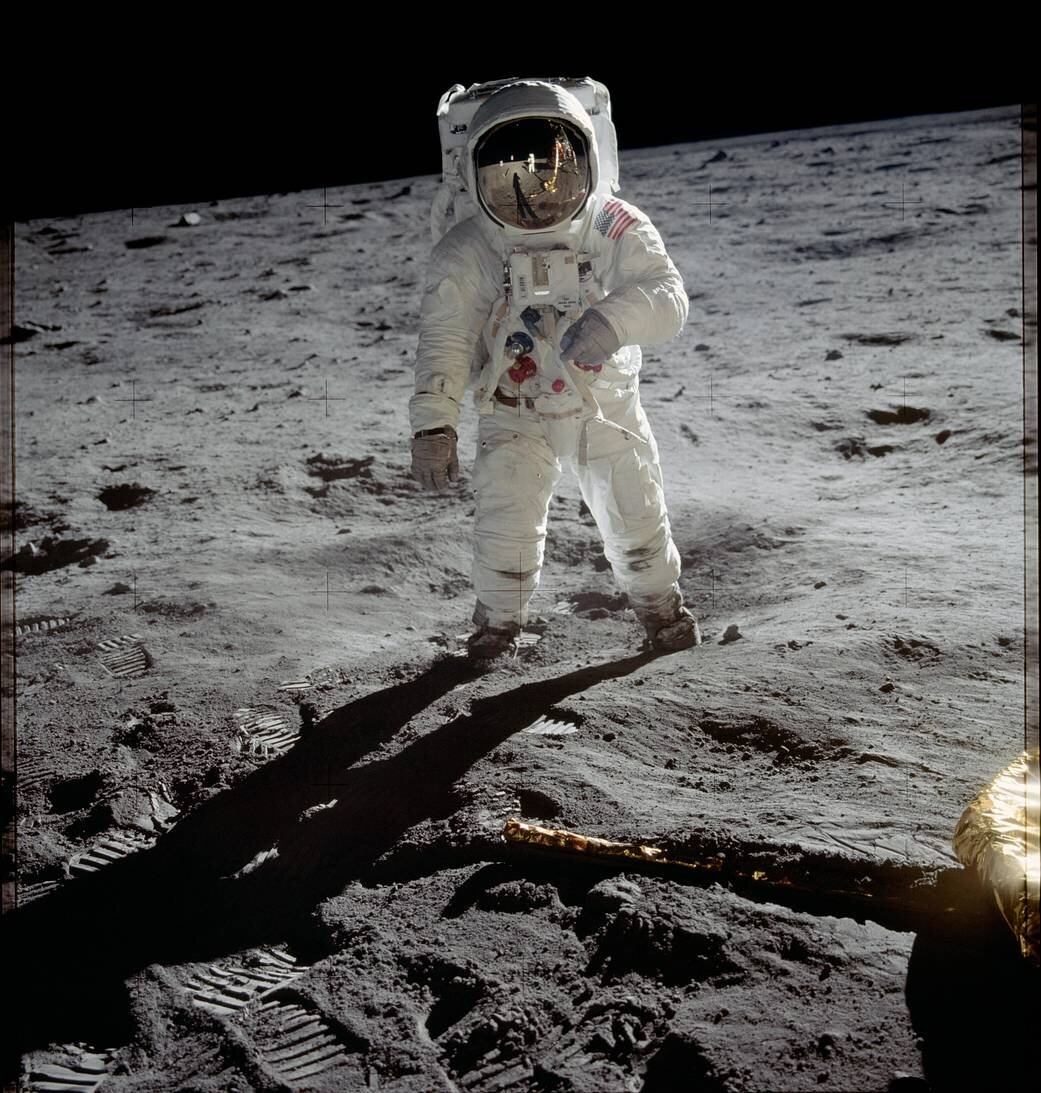

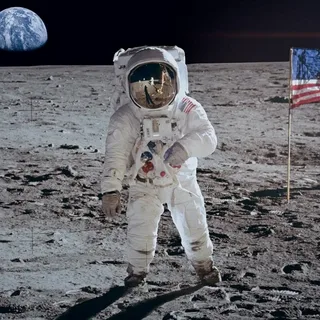

Predicted: []


In [38]:
image_1 = Image.open("/mnt/DATA2/dorin/imgs/moon/moon1.jpg")
image_2 = Image.open("/mnt/DATA2/dorin/imgs/moon/moon_near2.jpg")

image_1.show()
image_2.show()

image_tensor_1 = preprocess(image_1).unsqueeze(0)
image_tensor_2 = preprocess(image_2).unsqueeze(0)

generated = model.generate(image_tensor_1, image_tensor_2, max_new_tokens=10, do_sample=False)
# generated = model.generate(image_tensor_1, image_tensor_2, max_new_tokens=10, do_sample=True, top_k=3)

tokenizer = TransformTokenizer()
tokens = tokenizer.decode(generated[0], skip_special_tokens=True)
print(f"Predicted: {tokens}")

### ViT Encoder

In [3]:
from src.model import ViTImageEncoder, ImagePairEncoderViT

In [7]:
config = OmegaConf.load('configs/train_config_vit.yaml')

model = ImagePairEncoderViT(config.model.encoder)
preprocess = model.preprocess

In [10]:
image_path = 'assets/image.jpg'

image = Image.open(image_path)
image_tensor = preprocess(image).unsqueeze(0)
model(image_tensor, image_tensor).shape

torch.Size([1, 395, 512])

In [21]:
import torch.nn as nn
from torchvision.models import vit_b_16, ViT_B_16_Weights

weights = ViT_B_16_Weights.IMAGENET1K_V1
vit = vit_b_16(weights=weights)
vit.heads = nn.Identity()

### Image Preprocess

In [3]:
from torchvision.models import vit_b_16, ViT_B_16_Weights
from torchvision import transforms
from PIL import Image

weights = ViT_B_16_Weights.IMAGENET1K_V1
preprocess_transform = weights.transforms()


image_path = 'assets/image.jpg'

image = Image.open(image_path)
image_tensor = preprocess_transform(image).shape

По сути у ViT тут:
```
transform = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BILINEAR),  # Изменение размера до 256x256
    transforms.CenterCrop(224),  # Центральный кроп до 224x224
    transforms.ToTensor(),  # Преобразование в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Нормализация
])
```

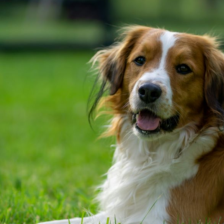

In [ ]:
from PIL import Image
from torchvision.transforms.functional import to_pil_image
import torch
from torchvision.models import ViT_B_16_Weights


weights = ViT_B_16_Weights.IMAGENET1K_V1
preprocess_transform = weights.transforms()

image_path = 'assets/image.jpg'
image = Image.open(image_path).convert("RGB")
image_tensor = preprocess_transform(image)

mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)

denorm_tensor = image_tensor * std + mean
denorm_tensor = torch.clamp(denorm_tensor, 0, 1)

pil_image = to_pil_image(denorm_tensor)
pil_image

In [10]:
from torchvision.models import EfficientNet_B3_Weights

weights = EfficientNet_B3_Weights.IMAGENET1K_V1
preprocess = weights.transforms()

У EfficientNet-B3 аналогично оригинальные размеры 300.
```
transform = transforms.Compose([
    transforms.Resize(320, interpolation=InterpolationMode.BICUBIC),  # Изменение размера до 320x320 с бикубической интерполяцией
    transforms.CenterCrop(300),  # Центральный кроп до 300x300
    transforms.ToTensor(),  # Преобразование в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Нормализация
])
```
- EfficientNet поддерживает произвольные размеры благодаря AdaptiveAvgPool2d.
- Это не "динамический препроцессинг" как в Qwen-VL, а гибкая CNN-архитектура.
- Но предобученные веса оптимальны только для native resolution.
- Для максимальной точности: ресайз до native size модели (лучше с паддингом, если не хотите кропа).

In [ ]:
from efficientnet_pytorch import EfficientNet

model_name = 'efficientnet-b3'
image_size = EfficientNet.get_image_size(model_name)
image_size

300

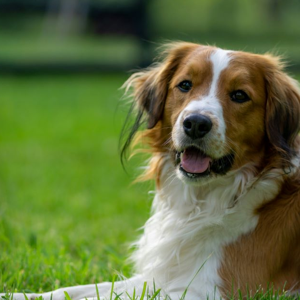

In [ ]:
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
import torch


transform = transforms.Compose([
    transforms.Resize(320, interpolation=InterpolationMode.BICUBIC), # меньшую сторону до 320
    transforms.CenterCrop(300),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

image_path = 'assets/image.jpg'
image = Image.open(image_path).convert("RGB")
image_tensor = transform(image)

# Денормализация
mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)

denorm_tensor = image_tensor * std + mean
denorm_tensor = torch.clamp(denorm_tensor, 0, 1)

# Преобразование в PIL
pil_image = to_pil_image(denorm_tensor)
pil_image

У нас же в EffNet:

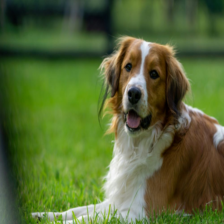

In [17]:
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
import torch


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

image_path = 'assets/image.jpg'
image = Image.open(image_path).convert("RGB")
image_tensor = transform(image)

mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)

denorm_tensor = image_tensor * std + mean
denorm_tensor = torch.clamp(denorm_tensor, 0, 1)

pil_image = to_pil_image(denorm_tensor)
pil_image

### Negative Dataset

In [19]:
from src.dataset import NegativeImagePairDataset, get_negative_pair_dataloaders

In [20]:
it = ImageTransformer()
tokenizer = TransformTokenizer()

In [4]:
data = NegativeImagePairDataset(
        root_dir = "/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
        batch_names = ["dataset_0", "dataset_1", "dataset_5", "dataset_9"],
        transformer = it,
        tokenizer = tokenizer,
        split = "train",
        val_size = 0.1,
        random_seed = 42,
        max_seq_len = 15,
        augmentation_p = 0.5
)

In [5]:
len(data)

354411

In [15]:
img1_t, img2_t, img1_aug_t, img2_aug_t, seq1_tensor, seq2_tensor = next(iter(data))

In [16]:
img1_t.shape

torch.Size([3, 224, 224])

In [17]:
seq2_tensor

tensor([ 1,  7,  9, 12,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

In [22]:
dataloaders = get_negative_pair_dataloaders(
        root_dir = "/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
        batch_names = ["dataset_0", "dataset_1", "dataset_5", "dataset_9"],
        transformer = it,
        tokenizer = tokenizer,
        batch_size = 32,
        num_workers = 4,
        val_size = 0.1)

In [25]:
for img1_t, img2_t, img1_aug_t, img2_aug_t, seq1_tensor, seq2_tensor in dataloaders["train"]:
    print(img1_t.shape)
    print(img1_aug_t.shape)
    print(seq1_tensor.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32, 3, 224, 224])
torch.Size([32, 15])


### Latency

In [3]:
config = OmegaConf.load('configs/train_config_vit.yaml')

# preprocess = transforms.Compose([
#             transforms.Resize((300, 300)),
#             transforms.ToTensor(),
#             transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
#         ])

preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

In [4]:
model = ImageTransformPredictor(config.model)

In [5]:
def count_parameters_in_m(model: torch.nn.Module) -> float:
    """Возвращает число обучаемых параметров модели в миллионах (M)."""
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params / 1e6  # → миллионы

count_parameters_in_m(model)

98.797824

In [6]:
checkpoint_path = 'checkpoints/itp_vit/checkpoint_epoch_100.pth'
# checkpoint_path = 'checkpoints/itp_011/checkpoint_epoch_50.pth'
# checkpoint_path = 'checkpoints/itp_010/checkpoint_epoch_16.pth' # хороший у 010
# checkpoint_path = 'checkpoints/itp_009/checkpoint_epoch_20.pth'
# checkpoint_path = 'checkpoints/itp_011_tune/checkpoint_epoch_15.pth'

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to('cpu')
model.eval()
print('ready')

ready


In [7]:
image_path = 'assets/image.jpg'

image = Image.open(image_path)


it = ImageTransformer()
transformed_image, sequence = it.transform(image, 0.3)
# transformed_image

In [8]:
latencies_ms = []


print("Замер latency...")
with torch.no_grad():
    for _ in tqdm(range(1000)):
        # Подготовка входа
        transformed_image, sequence = it.transform(image, 0.3)
        
        image_tensor = preprocess(image).unsqueeze(0)
        transformed_image_tensor = preprocess(transformed_image).unsqueeze(0)
    
        t0 = time.perf_counter()

        _ = model.generate(image_tensor, transformed_image_tensor, max_new_tokens=10, do_sample=False)

        t1 = time.perf_counter()

        latencies_ms.append((t1 - t0) * 1000)  # миллисекунды

Замер latency...


100%|██████████| 1000/1000 [04:06<00:00,  4.05it/s]


In [9]:
# Перцентили
lat = np.array(latencies_ms)
p50, p90, p95, p99 = np.percentile(lat, [50, 90, 95, 99])

# Вывод
print(f"\n📊 Результаты ({len(lat)} вызовов):")
print(f"p50: {p50:.1f} мс")
print(f"p90: {p90:.1f} мс")
print(f"p95: {p95:.1f} мс")
print(f"p99: {p99:.1f} мс")
print(f"mean: {lat.mean():.1f} мс ± {lat.std():.1f}")

ps = {
    'p50': p50, 'p90': p90, 'p95': p95, 'p99': p99,
    'mean': lat.mean(), 'std': lat.std(),
    'latencies': lat
}


📊 Результаты (1000 вызовов):
p50: 211.4 мс
p90: 238.1 мс
p95: 243.3 мс
p99: 256.7 мс
mean: 210.4 мс ± 22.1


In [15]:
# Перцентили
lat = np.array(latencies_ms)
p50, p90, p95, p99 = np.percentile(lat, [50, 90, 95, 99])

# Вывод
print(f"\n📊 Результаты ({len(lat)} вызовов):")
print(f"p50: {p50:.1f} мс")
print(f"p90: {p90:.1f} мс")
print(f"p95: {p95:.1f} мс")
print(f"p99: {p99:.1f} мс")
print(f"mean: {lat.mean():.1f} мс ± {lat.std():.1f}")

ps = {
    'p50': p50, 'p90': p90, 'p95': p95, 'p99': p99,
    'mean': lat.mean(), 'std': lat.std(),
    'latencies': lat
}


📊 Результаты (1000 вызовов):
p50: 129.0 мс
p90: 141.4 мс
p95: 145.2 мс
p99: 155.6 мс
mean: 130.4 мс ± 8.4


In [13]:
# Перцентили
lat = np.array(latencies_ms)
p50, p90, p95, p99 = np.percentile(lat, [50, 90, 95, 99])

# Вывод
print(f"\n📊 Результаты ({len(lat)} вызовов):")
print(f"p50: {p50:.1f} мс")
print(f"p90: {p90:.1f} мс")
print(f"p95: {p95:.1f} мс")
print(f"p99: {p99:.1f} мс")
print(f"mean: {lat.mean():.1f} мс ± {lat.std():.1f}")

ps = {
    'p50': p50, 'p90': p90, 'p95': p95, 'p99': p99,
    'mean': lat.mean(), 'std': lat.std(),
    'latencies': lat
}


📊 Результаты (1000 вызовов):
p50: 130.0 мс
p90: 141.9 мс
p95: 146.6 мс
p99: 155.8 мс
mean: 131.0 мс ± 8.4


In [24]:
import torch.nn as nn
import torch.nn.functional as F
from efficientnet_pytorch import EfficientNet

class SiamNet(nn.Module):
    def __init__(self):
        super(SiamNet, self).__init__()
        self.extractor = EfficientNet.from_pretrained('efficientnet-b3')
        del self.extractor._fc

        self.dropf = nn.Dropout(p=0.20)
        self.fc1 = nn.Linear(1536,1536)
        self.drop1 = nn.Dropout(p=0.20)
        self.fc2 = nn.Linear(1536,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, batch1: torch.Tensor, batch2: torch.Tensor) -> torch.Tensor:
        # Get embeddings for both batches
        emb1 = self.get_q(batch1)
        emb2 = self.get_q(batch2)

        # Create all possible combinations of embeddings
        batch_size1, emb_dim = emb1.size(0), emb1.size(1)
        batch_size2 = emb2.size(0)

        emb1_expanded = emb1.unsqueeze(1).expand(-1, batch_size2, -1)
        emb2_expanded = emb2.unsqueeze(0).expand(batch_size1, -1, -1)

        # dim: batch_size1 x batch_size2 x emb_dim
        combined_embeddings = torch.abs(emb1_expanded - emb2_expanded)
        combined_embeddings = combined_embeddings.view(-1, emb_dim)

        # Get logits
        logits = self.head_model(combined_embeddings)

        # Reshape logits to form a batch_size1 x batch_size2 matrix
        logits = logits.view(batch_size1, batch_size2)

        return logits

    def head_model(self, combined_embeddings):
        r = self.drop1(F.relu(self.fc1(combined_embeddings)))
        r = self.sigmoid(self.fc2(r))
        return r
    
    def forward_original(self, query, target, input_q=None, input_t=None, return_vectors=False):
        b = query.size(0)
        if input_q is None:
            q = self.extractor._conv_stem(query)
            q = self.extractor._bn0(q)
            for k,lay in enumerate(self.extractor._blocks):
                q = lay(q)
            q = self.extractor._conv_head(q)
            q = self.extractor._bn1(q)
            q = self.extractor._avg_pooling(q).view(b,-1)
            q = self.dropf(q)
        else:
            q = input_q

        if input_t is None:
            t = self.extractor._conv_stem(target)
            t = self.extractor._bn0(t)
            for k,lay in enumerate(self.extractor._blocks):
                t = lay(t)
            t = self.extractor._conv_head(t)
            t = self.extractor._bn1(t)
            t = self.extractor._avg_pooling(t).view(b,-1)
            t = self.dropf(t)
        else:
            t = input_t

        r = torch.abs(q-t)
        r = self.drop1(F.relu(self.fc1(r)))
        r = self.sigmoid(self.fc2(r))
        if return_vectors:
            return r, (q, t)
        else:
            return r

    def get_q(self, query):
        b = query.size(0)
        q = self.extractor._conv_stem(query)
        q = self.extractor._bn0(q)
        for k,lay in enumerate(self.extractor._blocks):
            q = lay(q)
        q = self.extractor._conv_head(q)
        q = self.extractor._bn1(q)
        q = self.extractor._avg_pooling(q).view(b,-1)
        q = self.dropf(q)
        return q

In [28]:
siamnet = SiamNet()

siamnet.to('cpu')
siamnet.eval()
print('ready')

preprocess = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

count_parameters_in_m(siamnet)

Loaded pretrained weights for efficientnet-b3
ready


13.058601

In [26]:
latencies_ms = []


print("Замер latency...")
with torch.no_grad():
    for _ in tqdm(range(1000)):
        # Подготовка входа
        transformed_image, sequence = it.transform(image, 0.3)
        
        image_tensor = preprocess(image).unsqueeze(0)
        transformed_image_tensor = preprocess(transformed_image).unsqueeze(0)
    
        t0 = time.perf_counter()

        _ = siamnet.forward_original(image_tensor, transformed_image_tensor)

        t1 = time.perf_counter()

        latencies_ms.append((t1 - t0) * 1000)  # миллисекунды

Замер latency...


100%|██████████| 1000/1000 [02:00<00:00,  8.33it/s]


In [27]:
lat = np.array(latencies_ms)
p50, p90, p95, p99 = np.percentile(lat, [50, 90, 95, 99])

# Вывод
print(f"\n📊 Результаты ({len(lat)} вызовов):")
print(f"p50: {p50:.1f} мс")
print(f"p90: {p90:.1f} мс")
print(f"p95: {p95:.1f} мс")
print(f"p99: {p99:.1f} мс")
print(f"mean: {lat.mean():.1f} мс ± {lat.std():.1f}")

ps = {
    'p50': p50, 'p90': p90, 'p95': p95, 'p99': p99,
    'mean': lat.mean(), 'std': lat.std(),
    'latencies': lat
}


📊 Результаты (1000 вызовов):
p50: 81.6 мс
p90: 88.0 мс
p95: 90.9 мс
p99: 95.6 мс
mean: 82.4 мс ± 4.4
